# CNN Cancer Detection Kaggle Mini-Project

Please download the zip file first from https://www.kaggle.com/c/histopathologic-cancer-detection/data

## 0 Import Libraries

In [5]:
# For data manipulation and analysis
import pandas as pd
import numpy as np
import os
import random
import zipfile

# For image processing
from PIL import Image
import matplotlib.pyplot as plt

# For creating and training the neural network model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# For data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For performance evaluation
from sklearn.metrics import roc_curve, auc


## Create paths


In [2]:
os.listdir()

['histopathologic-cancer-detection.zip', 'week3_proj.ipynb']

In [ ]:
# Define the zip file and the target directory
zip_file = 'histopathologic-cancer-detection.zip'
extract_dir = 'histopathologic-cancer-detection'

# Check if the directory exists
if not os.path.exists(extract_dir):
    # If it doesn't exist, create the directory
    os.makedirs(extract_dir)

# Extract the zip file
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [2]:
# create paths 
folder_path = 'histopathologic-cancer-detection'
train_path = os.path.join(folder_path, 'train')
test_path = os.path.join(folder_path, 'test')
label_path = os.path.join(folder_path, 'train_labels.csv')

## Step 1: Brief description of the problem and data

### Purpose
The purpose of this project is to identify metastatic cancer in small image patches taken from larger digital pathology scans.
Here is the link to the related kaggle competition: https://www.kaggle.com/c/histopathologic-cancer-detection/overview

### Data
The dataset consists of a .csv file with training images ids and a binary label (1/0) for cancer. It also consists of histopathologic scans of lymph notes stored as TIFF images, split into training and test datasets. 

    1 .csv file contains 220,025 rows with 2 columns (id, label)
    2 There are 220,025 traning images 
    3 There are 57,458 test images


In [3]:
train_images_count = len(os.listdir(train_path))
test_images_count = len(os.listdir(test_path))

In [4]:
train_images_count

220025

In [5]:
test_images_count

57458

### Read in train labels data

In [6]:
# read in label data
labels_df = pd.read_csv(label_path)
labels_df.head()

,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [19]:
labels_df.shape

(220025, 2)

### Set up data augmentation

In [5]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

### Set up preprocess and augment training data

In [6]:
def load_and_preprocess_image(image_id, train_path, target_size=(96, 96)):
    # Construct the file path for the TIFF image
    path = os.path.join(train_path, f"{image_id}.tif")
    
    # Use Pillow to open the image
    with Image.open(path) as img:
        # Resize the image and convert to RGB (in case it's not)
        img = img.resize(target_size).convert('RGB')
        
        # Convert the image to a NumPy array and normalize pixel values
        img_array = np.array(img) / 255.0
    
    return img_array

def train_generator(batch_size=32):
    while True:
        # Shuffle the dataset
        shuffled_indices = np.random.permutation(labels_df.index)
        for i in range(0, len(shuffled_indices), batch_size):
            batch_indices = shuffled_indices[i:i+batch_size]
            batch_images = []
            batch_labels = []
            for idx in batch_indices:
                row = labels_df.iloc[idx]
                image_id = row['id']
                label = row['label']
                image = load_and_preprocess_image(image_id, train_path)
                batch_images.append(image)
                batch_labels.append(label)
            batch_images = np.array(batch_images)
            batch_labels = np.array(batch_labels)
            
            # Create an iterator using flow
            iterator = datagen.flow(batch_images, batch_labels, batch_size=batch_size)
            
            # Use the next() function to get the next batch
            yield next(iterator)

## Step 2: Exploratory Data Analysis

label
0    130908
1     89117
Name: count, dtype: int64


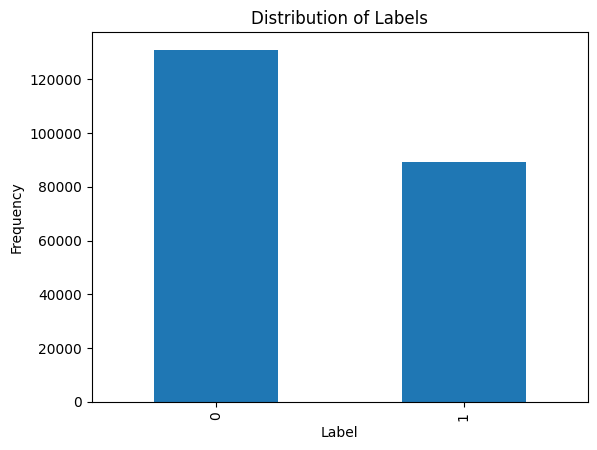

In [7]:
# View label distribution for training data
print(labels_df['label'].value_counts())
labels_df['label'].value_counts().plot(kind='bar')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

### Images
* Cancerous cells seem to show enlarged nuclei
* Cancerous cells seem to have more irregular cell shape

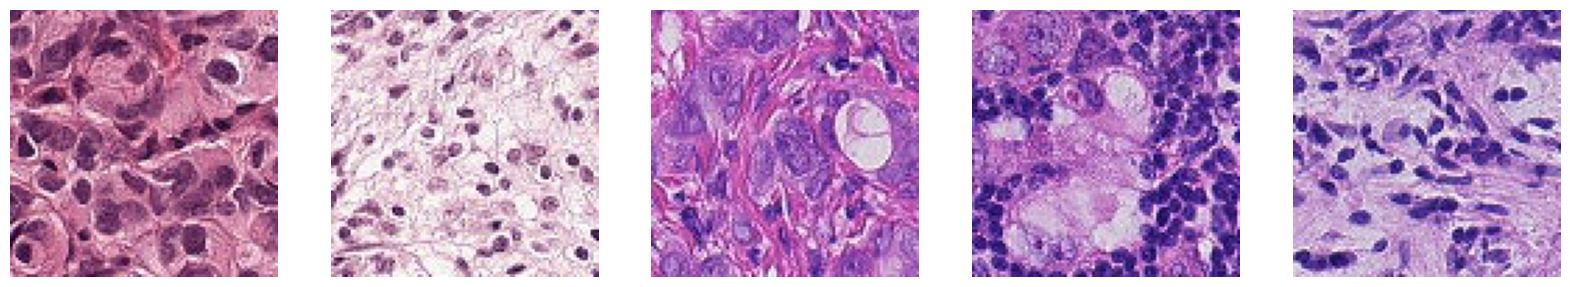

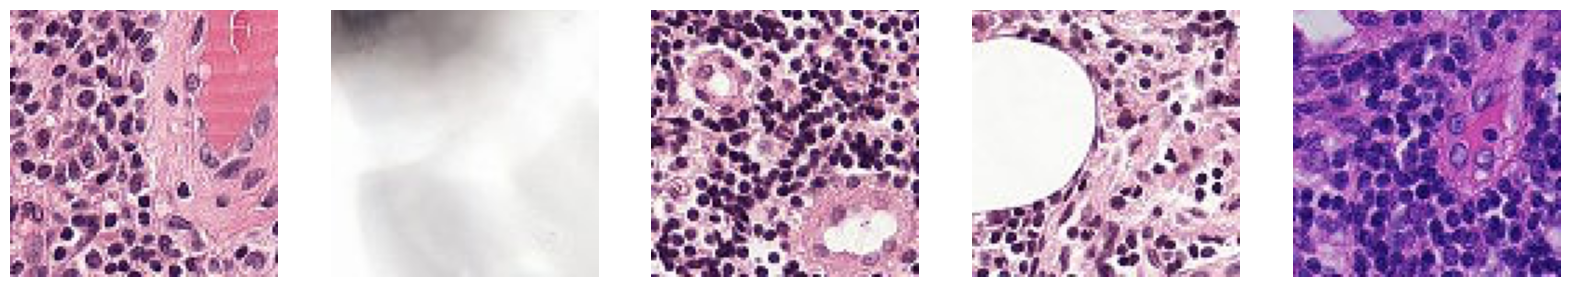

In [8]:
def show_sample_images(n=5, cancerous=True):
    if cancerous:
        sample_ids = labels_df[labels_df['label'] == 1]['id'].sample(n)
    else:
        sample_ids = labels_df[labels_df['label'] == 0]['id'].sample(n)
    
    fig, axes = plt.subplots(1, n, figsize=(20, 4))
    for ax, image_id in zip(axes, sample_ids):
        image_path = os.path.join(train_path, f"{image_id}.tif")
        image = Image.open(image_path)
        ax.imshow(image)
        ax.axis('off')
    plt.show()

# Show 5 cancerous sample images
show_sample_images(n=5, cancerous=True)

# Show 5 non-cancerous sample images
show_sample_images(n=5, cancerous=False)

### Image pixel intensity distribution
* Non-cancerous cells seem to have higher pixel intensity

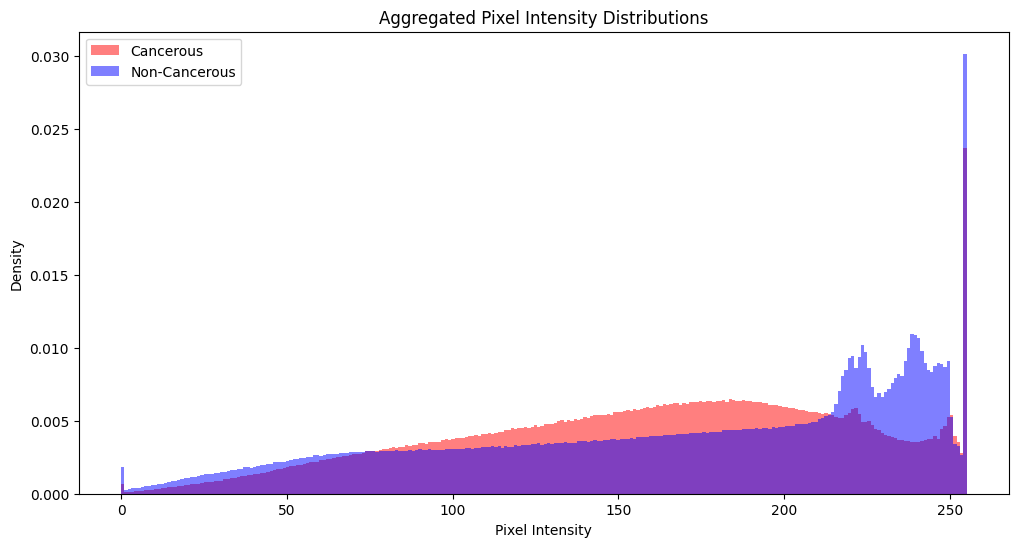

In [9]:
def plot_aggregated_distributions(sampled_ids, category_name, train_path, color):
    """
    Plot aggregated pixel intensity distributions for sampled image IDs.
    
    Parameters:
    - sampled_ids: List of image IDs to sample from.
    - category_name: 'Cancerous' or 'Non-Cancerous' for labeling.
    - train_path: Path to the directory containing training images.
    """
    # Initialize an empty array to store pixel values
    all_pixels = np.array([])
    
    # Load each image, flatten, and append pixel values
    for image_id in sampled_ids:
        image_path = os.path.join(train_path, f"{image_id}.tif")
        image = Image.open(image_path)
        image_array = np.array(image)
        all_pixels = np.append(all_pixels, image_array.ravel())  # Flatten and append
    
    # Plot histogram
    plt.hist(all_pixels, bins=256, color=color, alpha=0.5, label=category_name, density=True)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Density')
    plt.legend()

# Sample 1000 IDs from each category, or fewer if not available
sample_size = 100
cancerous_ids = labels_df[labels_df['label'] == 1].sample(n=min(sample_size, len(labels_df[labels_df['label'] == 1])), random_state=1)['id']
non_cancerous_ids = labels_df[labels_df['label'] == 0].sample(n=min(sample_size, len(labels_df[labels_df['label'] == 0])), random_state=1)['id']

plt.figure(figsize=(12, 6))
plot_aggregated_distributions(cancerous_ids, 'Cancerous', train_path, color='red')
plot_aggregated_distributions(non_cancerous_ids, 'Non-Cancerous', train_path, color='blue')
plt.title('Aggregated Pixel Intensity Distributions')
plt.show()


## Prepare test data

In [10]:
def get_test_ids(test_path):
    return [os.path.splitext(filename)[0] for filename in os.listdir(test_path)]

test_ids = get_test_ids(test_path)

## Step 3: Model Architecture

### Model Architecture 
* Convolutional layers: The model starts with 3 convolutional layers of increasing filter counts (32, 64, 128) followed by a max-pooling layers. They are responsible for extracting hierarchcical features from images, with deeper layers capturing more complex patterns 
* Activation function: We are using ReLU activatino functions to help introudce non-linearity to the model
* Pooling layers: We use a max-pooling layer to reduce the spatial dimensions of the feature maps to help make the model more invariant to small translations in the input image
* Flattening: We flatten 2D feature maps into 1D feature vector to connect the dense layers
* Dense Layers: A dense layer with 128 units and ReLU activation is used for further processing of the features. This is followed by a dropout layer (Dropout with 0.5 rate) to reduce overfitting by randomly setting a fraction of input units to 0 at each update during training.
* Output Layer: Finally, a dense layer with a single unit and a sigmoid activation function outputs the probability that the input image contains metastatic cancer.

### Rationale 
* Feature Extraction: The convolutional and max-pooling layers effectively extract and downsample features, making the model capable of recognizing patterns indicative of metastatic cancer in the histopathologic scans.
* Overfitting Mitigation: The dropout layer helps prevent the model from overfitting to the training data, a common concern when working with deep neural networks.
* Binary Classification: The sigmoid activation in the output layer is suitable for binary classification tasks, providing a probability score that can be thresholded to determine class membership.

### Architecture Comparison and Hyperparameter Tuning: 
* I did not have enough time to try different model architecture or try different hyperparemeters but below are some suggestions. 

* Different Depths: Try models with more or fewer convolutional layers to see how depth affects performance. Deeper models can capture more complex features but may be prone to overfitting and require more data to train effectively.
* Filter Sizes and Counts: Experiment with different sizes and numbers of filters in the convolutional layers. Larger filters or more filters may capture more information but increase computational complexity.
* Pooling Strategies: Besides max-pooling, try average pooling to see if it affects performance differently.
* Dense Layer Configuration: Vary the number and size of dense layers following the convolutional layers. More or larger dense layers can increase model capacity but also risk overfitting.
* Regularization Techniques: Besides dropout, consider other regularization methods like L2 regularization on the weights of the dense layers.
* Learning Rate and Optimizer: Experiment with different optimizers (SGD, Adam, RMSprop) and learning rates to find the best combination for training convergence.
* Batch Size and Epochs: Adjusting the batch size and number of epochs can affect the training dynamics. Smaller batches often provide more frequent updates and can lead to faster convergence, while too small batches might result in unstable training.

### Define CNN model

In [11]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(96, 96, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


c:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


### Compile model

In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731,905 (6.61 MB)

 Trainable params: 1,731,905 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

### train model

In [15]:
# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

model.fit(
    train_generator(batch_size=64),  # Increased batch size
    steps_per_epoch=len(labels_df) // 64,  # Adjusted steps per epoch
    epochs=10,
    callbacks=[early_stopping]  # Add early stopping
)

Epoch 1/10
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 849s 246ms/step - accuracy: 0.7585 - loss: 0.5025
Epoch 2/10


c:\Python312\Lib\site-packages\keras\src\callbacks\early_stopping.py:156: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


3437/3437 ━━━━━━━━━━━━━━━━━━━━ 803s 234ms/step - accuracy: 0.8398 - loss: 0.3713
Epoch 3/10
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 765s 223ms/step - accuracy: 0.8565 - loss: 0.3391
Epoch 4/10
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 761s 221ms/step - accuracy: 0.8679 - loss: 0.3168
Epoch 5/10
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 752s 219ms/step - accuracy: 0.8759 - loss: 0.3024
Epoch 6/10
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 760s 221ms/step - accuracy: 0.8812 - loss: 0.2929
Epoch 7/10
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 753s 219ms/step - accuracy: 0.8816 - loss: 0.2896
Epoch 8/10
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 758s 221ms/step - accuracy: 0.8887 - loss: 0.2764
Epoch 9/10
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 748s 218ms/step - accuracy: 0.8896 - loss: 0.2733
Epoch 10/10
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 753s 219ms/step - accuracy: 0.8934 - loss: 0.2662


## Step 4: Results and Analysis

In [16]:
def predict_test_images_in_batches(test_ids, test_path, model, batch_size=64):
    # Preprocess images in batches and predict
    predictions = []
    for i in range(0, len(test_ids), batch_size):
        batch_ids = test_ids[i:i+batch_size]
        batch_images = np.array([load_and_preprocess_image(test_id, test_path) for test_id in batch_ids])
        batch_preds = model.predict(batch_images)
        predictions.extend(batch_preds.squeeze().tolist())  # Adjust depending on model output shape
    
    prediction_table = pd.DataFrame({
        'test_id': test_ids,
        'prediction_probability': predictions
    })
    
    return prediction_table

# Use the function and pass the necessary arguments
test_predictions_table = predict_test_images_in_batches(test_ids, test_path, model)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━

In [23]:
test_predictions_table.head()

,test_id,prediction_probability
0,00006537328c33e284c973d7b39d340809f7271b,0.609584
1,0000ec92553fda4ce39889f9226ace43cae3364e,0.517361
2,00024a6dee61f12f7856b0fc6be20bc7a48ba3d2,0.029610
3,000253dfaa0be9d0d100283b22284ab2f6b643f6,0.019790
4,000270442cc15af719583a8172c87cd2bd9c7746,0.003611


In [28]:
# rename columns to id and label 
test_predictions_table.columns = ['id', 'label']
test_predictions_table.head()


,id,label
0,00006537328c33e284c973d7b39d340809f7271b,0.609584
1,0000ec92553fda4ce39889f9226ace43cae3364e,0.517361
2,00024a6dee61f12f7856b0fc6be20bc7a48ba3d2,0.029610
3,000253dfaa0be9d0d100283b22284ab2f6b643f6,0.019790
4,000270442cc15af719583a8172c87cd2bd9c7746,0.003611


### Distribution of Prediction Probabilities

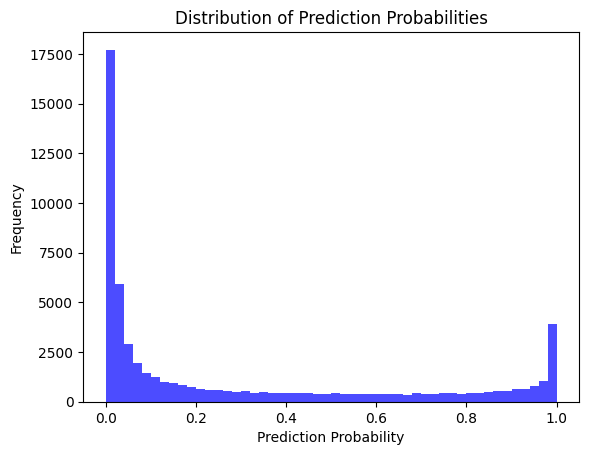

In [24]:
plt.hist(test_predictions_table['prediction_probability'], bins=50, alpha=0.7, color='blue')
plt.title('Distribution of Prediction Probabilities')
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.show()


### ROC Curve
It's impossible to get a ROC curve as we do not have the labels for the test dataset. 
However, the kaggle competition gives you a score based on the ROC curve. 
This was the score: Score: 0.8665, Public score: 0.8973
Assuming this is the ROC score with an AUC of 0.8665, the model seems to be performing decently. 

As stated before, I did not have time to test different hyperparameters but there are certainly room to tune hyperparameters to obtain a better model. 

In [29]:
# write test_predictions_table to a CSV file
test_predictions_table.to_csv('test_predictions.csv', index=False)

## Step 5: Conclusion

At first, the model and the predictions took a very long time. Playing around with the batch size helped to reduce the time it took to train and test the model. 

Below are some of the things I could try next time 
* Different Depths: Try models with more or fewer convolutional layers to see how depth affects performance. Deeper models can capture more complex features but may be prone to overfitting and require more data to train effectively.
* Filter Sizes and Counts: Experiment with different sizes and numbers of filters in the convolutional layers. Larger filters or more filters may capture more information but increase computational complexity.
* Pooling Strategies: Besides max-pooling, try average pooling to see if it affects performance differently.
* Dense Layer Configuration: Vary the number and size of dense layers following the convolutional layers. More or larger dense layers can increase model capacity but also risk overfitting.
* Regularization Techniques: Besides dropout, consider other regularization methods like L2 regularization on the weights of the dense layers.
* Learning Rate and Optimizer: Experiment with different optimizers (SGD, Adam, RMSprop) and learning rates to find the best combination for training convergence.
* Batch Size and Epochs: Adjusting the batch size and number of epochs can affect the training dynamics. Smaller batches often provide more frequent updates and can lead to faster convergence, while too small batches might result in unstable training.